# 📊 Modelo Predictivo de Recupero Mensual — Forum


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.seasonal import seasonal_decompose
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("⚠️ statsmodels no disponible")

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',
    'text.color': '#e2e8f0',
    'grid.color': '#334155',
    'axes.grid': True,
})

print("✅ Librerías cargadas")


✅ Librerías cargadas


## 1. Carga y Limpieza de Datos


In [2]:
ARCHIVO = "frm_2023-2026.xlsx"
HOJA = "recupero historico"

df = pd.read_excel(ARCHIVO, sheet_name=HOJA)
df.columns = df.columns.str.strip().str.rstrip('.')
df = df.rename(columns={
    'CLIENTE': 'CLIENTE',
    'CONTRATO': 'CONTRATO',
    'MANDANTE': 'MANDANTE',
    'ESTADO': 'ESTADO',
    'FECHA DE PAGO': 'FECHA_PAGO',
    'MONTO PAGADO': 'MONTO',
    'TIPO DE PAGO': 'TIPO_PAGO',
    'Saldo capital': 'SALDO_CAPITAL',
    'ESTADO 2': 'ESTADO2',
})

df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c], errors='ignore')
df['FECHA_PAGO'] = pd.to_datetime(df['FECHA_PAGO'])
df['ESTADO'] = df['ESTADO'].str.strip().str.upper()
df['GESTION'] = df['GESTION'].str.strip().str.upper()

sector_map = {
    'REGIONES': 'Regiones', 'Regiones ': 'Regiones', 'Regionnes': 'Regiones',
    'Santiagp': 'Santiago', 'E': 'Otros',
}
df['SECTOR'] = df['SECTOR'].replace(sector_map)

df['AÑO'] = df['FECHA_PAGO'].dt.year
df['MES_NUM'] = df['FECHA_PAGO'].dt.month
df['DIA'] = df['FECHA_PAGO'].dt.day
df['DIA_SEMANA'] = df['FECHA_PAGO'].dt.dayofweek
df['AÑO_MES'] = df['FECHA_PAGO'].dt.to_period('M')

print(f"Registros: {len(df):,}")
print(f"Rango: {df['FECHA_PAGO'].min().date()} → {df['FECHA_PAGO'].max().date()}")


Registros: 7,984
Rango: 2023-01-02 → 2026-03-09


In [3]:
monthly = df.groupby('AÑO_MES').agg(
    monto_total   = ('MONTO', 'sum'),
    num_pagos     = ('MONTO', 'count'),
    monto_prom    = ('MONTO', 'mean'),
    monto_mediana = ('MONTO', 'median'),
    monto_std     = ('MONTO', 'std'),
    max_pago      = ('MONTO', 'max'),
    dias_con_pago = ('FECHA_PAGO', lambda x: x.dt.day.nunique()),
    pct_judicial  = ('GESTION', lambda x: (x == 'JUDICIAL').mean()),
    pct_castigo   = ('ESTADO', lambda x: (x == 'CASTIGO').mean()),
).reset_index()

monthly['año'] = monthly['AÑO_MES'].dt.year
monthly['mes'] = monthly['AÑO_MES'].dt.month
monthly['dias_mes'] = monthly['AÑO_MES'].apply(lambda p: p.days_in_month)

MES_ACTUAL = monthly.iloc[-1]
historico = monthly.iloc[:-1].copy().reset_index(drop=True)

print(f"Meses históricos completos: {len(historico)}")
print(f"Mes parcial: {MES_ACTUAL['AÑO_MES']} — {MES_ACTUAL['num_pagos']:.0f} pagos, ${MES_ACTUAL['monto_total']:,.0f}")


Meses históricos completos: 38
Mes parcial: 2026-03 — 30 pagos, $72,813,690


## 2. Análisis Exploratorio


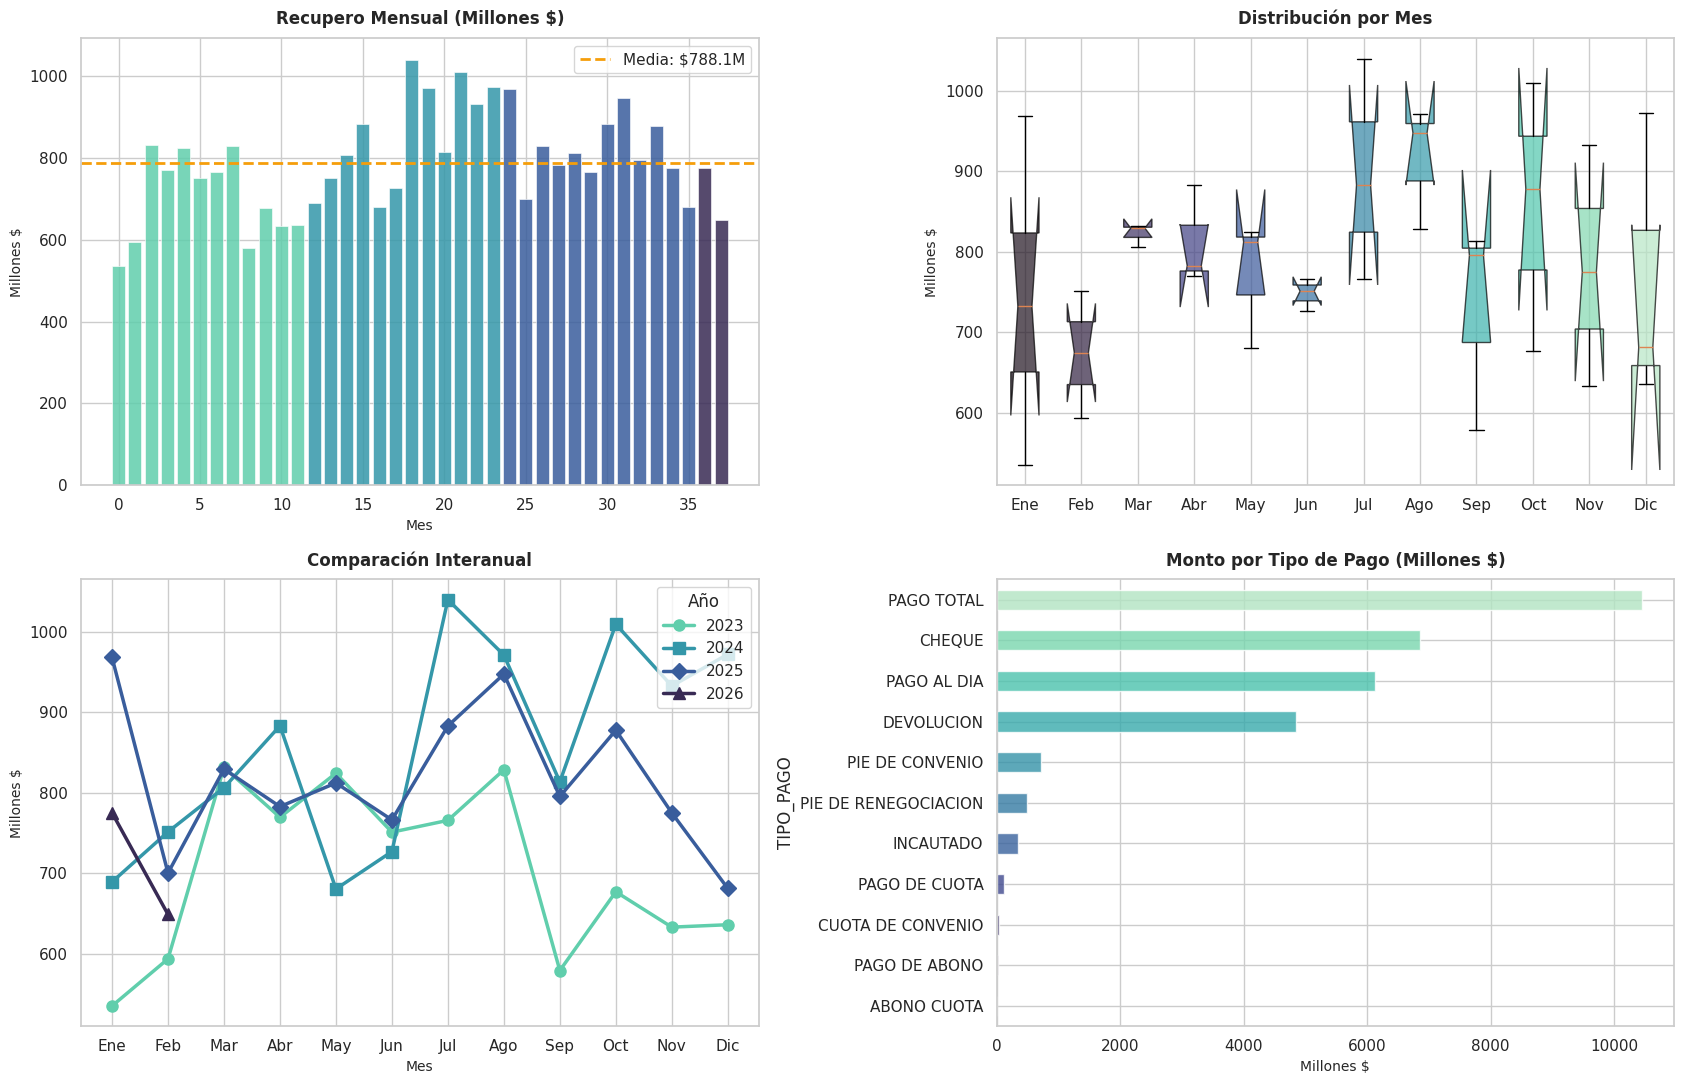

In [4]:

sns.set_theme(style="whitegrid", context="notebook")
palette = sns.color_palette("mako_r", n_colors=4)

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
meses_lbl = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# Color by year
historico_plot = historico.copy()
colors = [palette[int(y) - 2023] for y in historico_plot['año']]

# 1. Monthly recovery bar chart
ax1 = axes[0, 0]
bars = ax1.bar(range(len(historico_plot)), historico_plot['monto_total'] / 1e6, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.axhline(historico['monto_total'].mean() / 1e6, color='#f59e0b', ls='--', lw=2, label=f'Media: ${historico["monto_total"].mean()/1e6:.1f}M')
ax1.set_title('Recupero Mensual (Millones $)', fontweight='bold', fontsize=12, pad=10)
ax1.set_ylabel('Millones $', fontsize=10)
ax1.set_xlabel('Mes', fontsize=10)
ax1.legend(loc='upper right')

# 2. Boxplot by month
ax2 = axes[0, 1]
box_data = [historico[historico['mes'] == m]['monto_total'].values / 1e6 for m in range(1, 13)]
bp = ax2.boxplot(box_data, tick_labels=meses_lbl, patch_artist=True, notch=True)
colors_box = sns.color_palette("mako", n_colors=12)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title('Distribución por Mes', fontweight='bold', fontsize=12, pad=10)
ax2.set_ylabel('Millones $', fontsize=10)

# 3. Inter-year comparison
ax3 = axes[1, 0]
for yr, col, marker in [(2023, palette[0], 'o'), (2024, palette[1], 's'), (2025, palette[2], 'D'), (2026, palette[3], '^')]:
    sub = historico[historico['año'] == yr]
    if len(sub) > 0:
        ax3.plot(sub['mes'].values, sub['monto_total'].values / 1e6,
                marker=marker, color=col, label=str(yr), linewidth=2.5, markersize=8)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(meses_lbl)
ax3.set_title('Comparación Interanual', fontweight='bold', fontsize=12, pad=10)
ax3.set_ylabel('Millones $', fontsize=10)
ax3.set_xlabel('Mes', fontsize=10)
ax3.legend(title='Año', loc='upper right')

# 4. Payment type distribution
ax4 = axes[1, 1]
tp = df.groupby('TIPO_PAGO')['MONTO'].sum().sort_values(ascending=True) / 1e6
colors_bar = sns.color_palette("mako", n_colors=len(tp))
tp.plot(kind='barh', ax=ax4, color=colors_bar, alpha=0.8, edgecolor='white')
ax4.set_title('Monto por Tipo de Pago (Millones $)', fontweight='bold', fontsize=12, pad=10)
ax4.set_xlabel('Millones $', fontsize=10)

plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.1 Descomposición de la serie


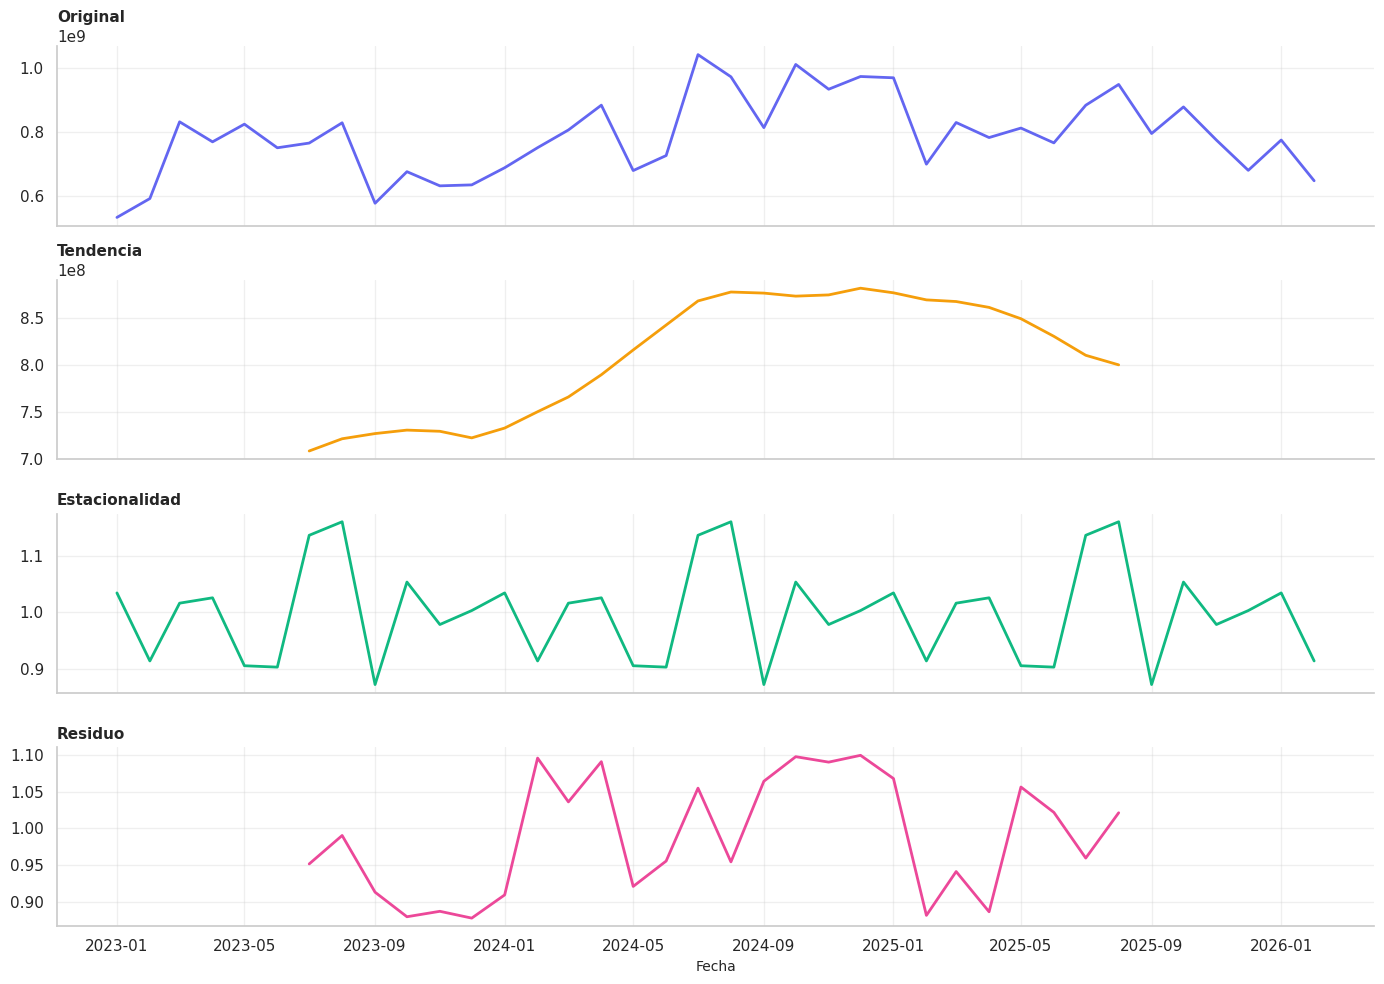

Índices estacionales:
  Ene: 1.0341
  Feb: 0.9139
  Mar: 1.0160
  Abr: 1.0254
  May: 0.9054
  Jun: 0.9030
  Jul: 1.1359
  Ago: 1.1597
  Sep: 0.8722
  Oct: 1.0532
  Nov: 0.9782
  Dic: 1.0029


In [5]:
if HAS_STATSMODELS:
    ts = pd.Series(
        historico['monto_total'].values,
        index=pd.date_range(start='2023-01', periods=len(historico), freq='MS')
    )
    decomp = seasonal_decompose(ts, model='multiplicative', period=12)
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    
    # Define colors for each component
    colors = ['#6366f1', '#f59e0b', '#10b981', '#ec4899']
    titles = ['Original', 'Tendencia', 'Estacionalidad', 'Residuo']
    
    for ax, data, color, title in zip(axes, 
        [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
        colors, titles):
        ax.plot(data, color=color, linewidth=2)
        ax.set_title(title, fontweight='bold', fontsize=11, loc='left')
        ax.set_ylabel('')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Fecha', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('02_descomposicion.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    seasonal_stl = decomp.seasonal[:12].values
    print("Índices estacionales:")
    for i, (m, s) in enumerate(zip(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], seasonal_stl)):
        print(f"  {m}: {s:.4f}")
else:
    print("⚠️ statsmodels no disponible")
    seasonal_stl = None


### 2.2 Análisis Estadístico Profundo


In [6]:
from scipy import stats

y = historico['monto_total'].values

print("=" * 70)
print("  ESTADÍSTICAS DESCRIPTIVAS — Serie Mensual (36 meses)")
print("=" * 70)

print(f"\n📊 MEDIDAS DE TENDENCIA CENTRAL:")
print(f"  Media aritmética:          ${np.mean(y):>15,.0f}")
print(f"  Mediana:                   ${np.median(y):>15,.0f}")

print(f"\n📏 MEDIDAS DE DISPERSIÓN:")
print(f"  Varianza:                  ${np.var(y, ddof=1):>15,.0f}")
print(f"  Desviación estándar:       ${np.std(y, ddof=1):>15,.0f}")
print(f"  Coeficiente de variación:   {np.std(y, ddof=1)/np.mean(y)*100:>14.1f} %")
print(f"  Rango:                     ${np.max(y) - np.min(y):>15,.0f}")
print(f"  Rango intercuartil (IQR):  ${np.percentile(y, 75) - np.percentile(y, 25):>15,.0f}")

print(f"\n📐 MEDIDAS DE FORMA:")
print(f"  Asimetría (skewness):      {stats.skew(y):>15.3f}")
print(f"  Curtosis (exceso):         {stats.kurtosis(y):>15.3f}")
skew = stats.skew(y)
print(f"  → {'Distribución asimétrica positiva (cola a la derecha)' if skew > 0.5 else 'Distribución asimétrica negativa (cola a la izquierda)' if skew < -0.5 else 'Distribución aproximadamente simétrica'}")

print(f"\n📊 PERCENTILES:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  P{p:>2}:  ${np.percentile(y, p):>15,.0f}")

print(f"\n🔍 DETECCIÓN DE OUTLIERS (IQR x1.5):")
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = y[(y < lower) | (y > upper)]
print(f"  Límite inferior:           ${lower:>15,.0f}")
print(f"  Límite superior:           ${upper:>15,.0f}")
print(f"  Outliers detectados:       {len(outliers):>15}")

print(f"\n📈 COEFICIENTE DE GINI:")
def gini(arr):
    arr = np.sort(arr)
    n = len(arr)
    cumsum = np.cumsum(arr)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n
gini_val = gini(y)
print(f"  Coeficiente de Gini:       {gini_val:>15.3f}")

print(f"\n🎯 TEST DE NORMALIDAD (Shapiro-Wilk):")
stat, p_value = stats.shapiro(y)
print(f"  Estadístico W:             {stat:>15.4f}")
print(f"  Valor p:                   {p_value:>15.4f}")
print(f"  → {'Distribución NORMAL' if p_value > 0.05 else 'Distribución NO normal'}")

print("=" * 70)


  ESTADÍSTICAS DESCRIPTIVAS — Serie Mensual (36 meses)

📊 MEDIDAS DE TENDENCIA CENTRAL:
  Media aritmética:          $    788,093,199
  Mediana:                   $    779,049,323

📏 MEDIDAS DE DISPERSIÓN:
  Varianza:                  $15,326,311,588,471,692
  Desviación estándar:       $    123,799,481
  Coeficiente de variación:             15.7 %
  Rango:                     $    505,351,119
  Rango intercuartil (IQR):  $    174,434,229

📐 MEDIDAS DE FORMA:
  Asimetría (skewness):                0.095
  Curtosis (exceso):                  -0.557
  → Distribución aproximadamente simétrica

📊 PERCENTILES:
  P 5:  $    591,320,095
  P10:  $    635,060,216
  P25:  $    691,960,352
  P50:  $    779,049,323
  P75:  $    866,394,581
  P90:  $    969,331,131
  P95:  $    978,026,914

🔍 DETECCIÓN DE OUTLIERS (IQR x1.5):
  Límite inferior:           $    430,309,008
  Límite superior:           $  1,128,045,924
  Outliers detectados:                     0

📈 COEFICIENTE DE GINI:
  Coeficiente

### 2.3 Autocorrelación y Estacionariedad


  AUTOCORRELACIÓN Y ESTACIONARIEDAD


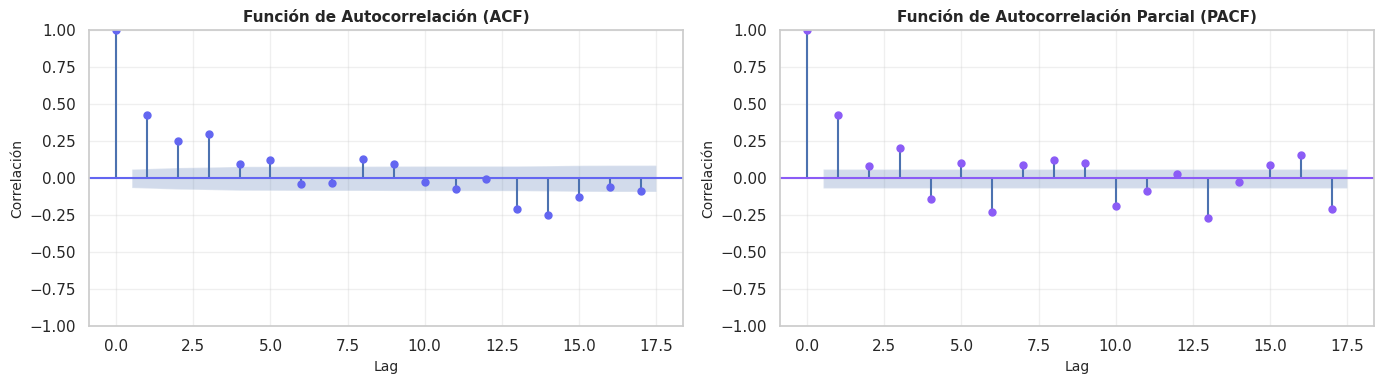


📊 Principales autocorrelaciones:
  Lag  1: 0.425
  Lag  2: 0.249
  Lag  3: 0.302
  Lag  6: -0.042
  Lag 12: -0.005

🔄 TEST DICKEY-FULLER AUMENTADO:
  Estadístico ADF:                    -3.9051
  Valor p:                            0.0020
  → Serie ESTACIONARIA

🔄 TEST KPSS:
  Estadístico KPSS:                    0.3391
  Valor p:                            0.1000
  → Serie ESTACIONARIA


/tmp/ipykernel_66127/3394735924.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(y, regression='c', nlags='auto')


In [7]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("=" * 70)
print("  AUTOCORRELACIÓN Y ESTACIONARIEDAD")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot
plot_acf(y, lags=17, ax=axes[0], color='#6366f1', alpha=0.7)
axes[0].set_title('Función de Autocorrelación (ACF)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Lag', fontsize=10)
axes[0].set_ylabel('Correlación', fontsize=10)
axes[0].grid(True, alpha=0.3)

# PACF plot
plot_pacf(y, lags=17, ax=axes[1], color='#8b5cf6', method='ywm', alpha=0.7)
axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Lag', fontsize=10)
axes[1].set_ylabel('Correlación', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_autocorr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Principales autocorrelaciones:")
acf_vals = np.correlate(y - y.mean(), y - y.mean(), mode='full')
acf_vals = acf_vals[len(acf_vals)//2:][:18] / acf_vals[len(acf_vals)//2]
for lag in [1, 2, 3, 6, 12]:
    print(f"  Lag {lag:>2}: {acf_vals[lag]:.3f}")

print(f"\n🔄 TEST DICKEY-FULLER AUMENTADO:")
adf = adfuller(y, autolag='AIC')
print(f"  Estadístico ADF:            {adf[0]:>15.4f}")
print(f"  Valor p:                   {adf[1]:>15.4f}")
print(f"  → {'Serie ESTACIONARIA' if adf[1] < 0.05 else 'Serie NO estacionaria'}")

print(f"\n🔄 TEST KPSS:")
kp = kpss(y, regression='c', nlags='auto')
print(f"  Estadístico KPSS:           {kp[0]:>15.4f}")
print(f"  Valor p:                   {kp[1]:>15.4f}")
print(f"  → {'Serie ESTACIONARIA' if kp[1] > 0.05 else 'Serie NO estacionaria'}")

print("=" * 70)


### 2.4 Correlaciones entre Variables


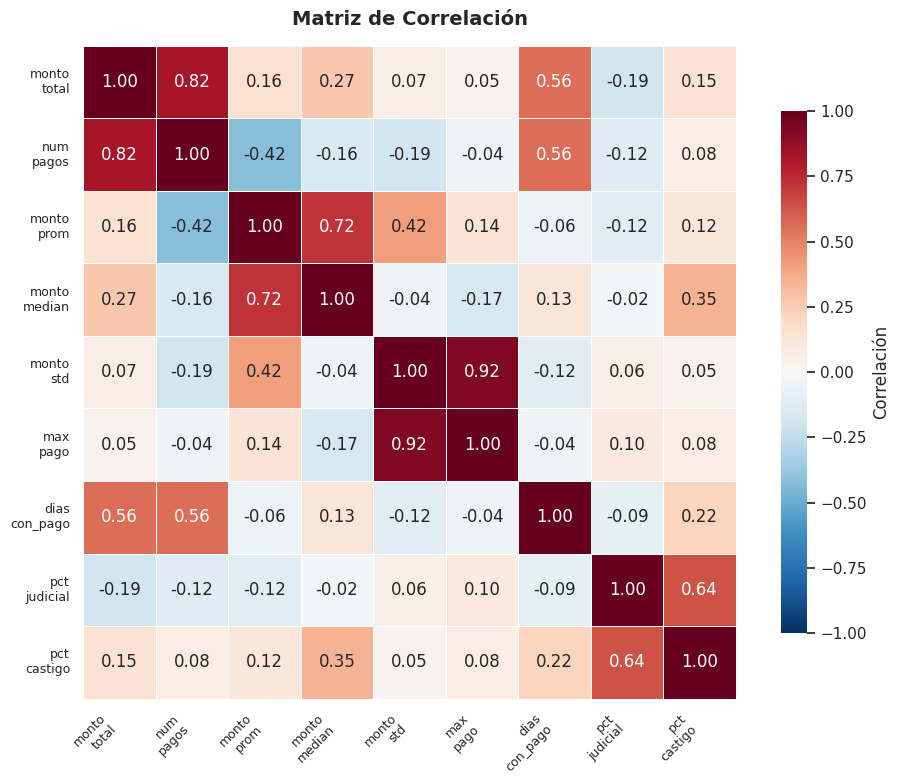


📊 Correlaciones con monto_total:
  num_pagos           :   0.822
  dias_con_pago       :   0.556
  monto_mediana       :   0.268
  pct_judicial        :  -0.193
  monto_prom          :   0.156
  pct_castigo         :   0.154
  monto_std           :   0.065
  max_pago            :   0.046


In [8]:
numeric_cols = ['monto_total', 'num_pagos', 'monto_prom', 'monto_mediana', 
                'monto_std', 'max_pago', 'dias_con_pago', 'pct_judicial', 'pct_castigo']
corr = historico[numeric_cols].corr()

# Create shorter labels for display
labels = ['monto\ntotal', 'num\npagos', 'monto\nprom', 'monto\nmedian', 
          'monto\nstd', 'max\npago', 'dias\ncon_pago', 'pct\njudicial', 'pct\ncastigo']

plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr, 
    annot=True, 
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Correlación', 'shrink': 0.8})

ax.set_title('Matriz de Correlación', fontweight='bold', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('04_corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Correlaciones con monto_total:")
corr_with = corr['monto_total'].drop('monto_total').sort_values(key=abs, ascending=False)
for col, val in corr_with.items():
    print(f"  {col:<20}: {val:>7.3f}")


In [9]:
print(f"\n📅 ESTADÍSTICAS POR AÑO:")
yearly = historico.groupby('año')['monto_total'].agg(['mean', 'std', 'min', 'max', 'sum'])
yearly['cv'] = yearly['std'] / yearly['mean'] * 100
yearly['crecimiento'] = yearly['mean'].pct_change() * 100
print(yearly.to_string())

print(f"\n📆 ESTADÍSTICAS POR MES (Patrón Estacional):")
monthly_stats = historico.groupby('mes')['monto_total'].agg(['mean', 'std', 'min', 'max'])
monthly_stats['cv'] = monthly_stats['std'] / monthly_stats['mean'] * 100
meses_lbl = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
monthly_stats.index = [meses_lbl[m-1] for m in monthly_stats.index]
print(monthly_stats.to_string())



📅 ESTADÍSTICAS POR AÑO:
              mean           std        min         max          sum         cv  crecimiento
año                                                                                         
2023  7.020513e+08  1.059509e+08  534935868   831714514   8424615206  15.091617          NaN
2024  8.565355e+08  1.285003e+08  680445175  1040286987  10278426371  15.002329    22.004698
2025  8.183789e+08  8.857990e+07  681144971   968415197   9820546803  10.823825    -4.454763
2026  7.119766e+08  8.944919e+07  648726453   775226713   1423953166  12.563502   -13.001596

📆 ESTADÍSTICAS POR MES (Patrón Estacional):
             mean           std        min         max         cv
Ene  7.419390e+08  1.807701e+08  534935868   968415197  24.364555
Feb  6.734983e+08  6.785160e+07  593495619   751464724  10.074501
Mar  8.225639e+08  1.405367e+07  806382330   831714514   1.708521
Abr  8.119613e+08  6.224682e+07  769584711   883427136   7.666230
May  7.724026e+08  7.986663e+07  680445175

## 3. Modelos de Machine Learning


In [10]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Features para predicción de num_pagos y monto_total

def crear_features(df_hist):
    """Crea features lagged para los modelos."""
    feat = pd.DataFrame(index=df_hist.index)
    
    # Features básicos
    feat['año'] = df_hist['año']
    feat['mes'] = df_hist['mes']
    
    # Features de lags (valores anteriores)
    for lag in [1, 2, 3, 6, 12]:
        feat[f'monto_lag_{lag}'] = df_hist['monto_total'].shift(lag)
        feat[f'num_pagos_lag_{lag}'] = df_hist['num_pagos'].shift(lag)
    
    # Medias móviles
    for window in [3, 6, 12]:
        feat[f'monto_ma_{window}'] = df_hist['monto_total'].rolling(window).mean()
        feat[f'num_pagos_ma_{window}'] = df_hist['num_pagos'].rolling(window).mean()
    
    # Desviación estándar móvil
    feat['monto_std_6'] = df_hist['monto_total'].rolling(6).std()
    feat['num_pagos_std_6'] = df_hist['num_pagos'].rolling(6).std()
    
    # Tendencia (diferencia con mes anterior)
    feat['monto_diff_1'] = df_hist['monto_total'].diff(1)
    feat['monto_diff_12'] = df_hist['monto_total'].diff(12)
    
    # Porcentaje de judiciales (puede afectar el monto)
    feat['pct_judicial'] = df_hist['pct_judicial']
    feat['pct_castigo'] = df_hist['pct_castigo']
    
    # Días del mes (para estimar recuperación parcial)
    feat['dias_mes'] = df_hist['dias_mes']
    
    return feat

# Crear features
X = crear_features(historico)

# Targets
y_pagos = historico['num_pagos'].values
y_monto = historico['monto_total'].values

# Eliminar filas con NaN (por los lags)
valid_idx = X.dropna().index
X_clean = X.loc[valid_idx].values
y_pagos_clean = historico.loc[valid_idx, 'num_pagos'].values
y_monto_clean = historico.loc[valid_idx, 'monto_total'].values

print(f"Features creados: {X.shape[1]}")
print(f"Muestras válidas para entrenamiento: {len(X_clean)}")
print(f"\nFeatures: {list(X.columns)}")

# Imports para modelos adicionales
import xgboost as xgb
import lightgbm as lgb


Features creados: 25
Muestras válidas para entrenamiento: 26

Features: ['año', 'mes', 'monto_lag_1', 'num_pagos_lag_1', 'monto_lag_2', 'num_pagos_lag_2', 'monto_lag_3', 'num_pagos_lag_3', 'monto_lag_6', 'num_pagos_lag_6', 'monto_lag_12', 'num_pagos_lag_12', 'monto_ma_3', 'num_pagos_ma_3', 'monto_ma_6', 'num_pagos_ma_6', 'monto_ma_12', 'num_pagos_ma_12', 'monto_std_6', 'num_pagos_std_6', 'monto_diff_1', 'monto_diff_12', 'pct_judicial', 'pct_castigo', 'dias_mes']


In [11]:
# ============================================================
# ENTRENAMIENTO DE MODELOS
# ============================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Modelos para num_pagos
modelos_pagos = {
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42, verbose=-1),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=42),
}

# Modelos para monto_total
modelos_monto = {
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42, verbose=-1),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=42),
}

# Validación cruzada con TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

print("=" * 70)
print("  RESULTADOS - VALIDACIÓN CRUZADA")
print("=" * 70)

resultados_pagos = {}
resultados_monto = {}

# Evaluar modelos para num_pagos
print("\n📊 PREDICCIÓN DE NÚMERO DE PAGOS:")
print("-" * 60)
for nombre, modelo in modelos_pagos.items():
    mae_scores = []
    mape_scores = []
    for train_idx, val_idx in tscv.split(X_scaled):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y_pagos_clean[train_idx], y_pagos_clean[val_idx]
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        mape_scores.append(mean_absolute_percentage_error(y_val, y_pred) * 100)
    resultados_pagos[nombre] = {
        'MAE': np.mean(mae_scores),
        'MAPE': np.mean(mape_scores),
        'weights': 1 / (np.mean(mape_scores) + 1)  # Inverse MAPE as weight
    }
    print(f"  {nombre:20s} | MAE: {np.mean(mae_scores):8.2f} | MAPE: {np.mean(mape_scores):6.2f}%")

# Evaluar modelos para monto_total
print("\n💰 PREDICCIÓN DE MONTO TOTAL:")
print("-" * 60)
for nombre, modelo in modelos_monto.items():
    mae_scores = []
    mape_scores = []
    for train_idx, val_idx in tscv.split(X_scaled):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y_monto_clean[train_idx], y_monto_clean[val_idx]
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_val)
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        mape_scores.append(mean_absolute_percentage_error(y_val, y_pred) * 100)
    resultados_monto[nombre] = {
        'MAE': np.mean(mae_scores),
        'MAPE': np.mean(mape_scores),
        'weights': 1 / (np.mean(mape_scores) + 1)  # Inverse MAPE as weight
    }
    print(f"  {nombre:20s} | MAE: ${np.mean(mae_scores)/1e6:7.2f}M | MAPE: {np.mean(mape_scores):6.2f}%")

# Calcular pesos normalizados para ensemble
total_weight_pagos = sum(r['weights'] for r in resultados_pagos.values())
total_weight_monto = sum(r['weights'] for r in resultados_monto.values())

for nombre in resultados_pagos:
    resultados_pagos[nombre]['normalized_weight'] = resultados_pagos[nombre]['weights'] / total_weight_pagos
for nombre in resultados_monto:
    resultados_monto[nombre]['normalized_weight'] = resultados_monto[nombre]['weights'] / total_weight_monto

print("\n📊 Pesos del ensemble (basados en MAPE):")
print("-" * 60)
print("  Pagos: ", end="")
for nombre, r in resultados_pagos.items():
    print(f"{nombre}={r['normalized_weight']:.2%}, ", end="")
print()
print("  Monto: ", end="")
for nombre, r in resultados_monto.items():
    print(f"{nombre}={r['normalized_weight']:.2%}, ", end="")
print()

print("=" * 70)


  RESULTADOS - VALIDACIÓN CRUZADA

📊 PREDICCIÓN DE NÚMERO DE PAGOS:
------------------------------------------------------------
  XGBoost              | MAE:    26.48 | MAPE:  11.70%
  LightGBM             | MAE:    30.69 | MAPE:  13.38%
  RandomForest         | MAE:    27.06 | MAPE:  11.65%
  GradientBoosting     | MAE:    23.13 | MAPE:  10.30%
  ExtraTrees           | MAE:    27.07 | MAPE:  11.83%

💰 PREDICCIÓN DE MONTO TOTAL:
------------------------------------------------------------
  XGBoost              | MAE: $  87.46M | MAPE:  10.64%
  LightGBM             | MAE: $ 113.60M | MAPE:  13.34%
  RandomForest         | MAE: $  91.60M | MAPE:  10.51%
  GradientBoosting     | MAE: $ 100.48M | MAPE:  11.74%
  ExtraTrees           | MAE: $  99.49M | MAPE:  11.53%

📊 Pesos del ensemble (basados en MAPE):
------------------------------------------------------------
  Pagos: XGBoost=19.99%, LightGBM=17.66%, RandomForest=20.08%, GradientBoosting=22.47%, ExtraTrees=19.79%, 
  Monto: XGBoos

In [12]:
# ============================================================
# PREDICCIÓN PARA EL MES ACTUAL
# ============================================================

# Calcular días transcurridos desde el último pago
ultimo_pago = df['FECHA_PAGO'].max()
inicio_mes = MES_ACTUAL['AÑO_MES'].to_timestamp()
dias_transcurridos = (ultimo_pago - inicio_mes).days + 1
dias_transcurridos = min(dias_transcurridos, MES_ACTUAL['dias_mes'])
dias_transcurridos = max(dias_transcurridos, 1)

pagos_hasta_ahora = MES_ACTUAL['num_pagos']
monto_hasta_ahora = MES_ACTUAL['monto_total']
dias_mes = MES_ACTUAL['dias_mes']

print(f"📅 Mes actual: {MES_ACTUAL['AÑO_MES']}")
print(f"   Días del mes: {dias_mes}")
print(f"   Días transcurridos desde último pago: {dias_transcurridos}")
print(f"   Pagos registrados: {pagos_hasta_ahora}")
print(f"   Monto registrado: ${monto_hasta_ahora:,.0f}")
print()

# Crear features para predicción
sig_mes = pd.DataFrame({
    'año': [MES_ACTUAL['año']],
    'mes': [MES_ACTUAL['mes']],
    'monto_total': [MES_ACTUAL['monto_total']],
    'num_pagos': [MES_ACTUAL['num_pagos']],
    'pct_judicial': [MES_ACTUAL['pct_judicial']],
    'pct_castigo': [MES_ACTUAL['pct_castigo']],
    'dias_mes': [MES_ACTUAL['dias_mes']],
})

hist_temp = pd.concat([historico, sig_mes], ignore_index=True)
X_pred = crear_features(hist_temp)
X_pred_last = X_pred.iloc[-1:].values
X_pred_scaled = scaler.transform(X_pred_last)

# Entrenar modelos con todos los datos y predecir
print("=" * 70)
print("  PREDICCIONES PARA EL MES ACTUAL")
print("=" * 70)

# Predicción num_pagos
pred_pagos = {}
for nombre, modelo in modelos_pagos.items():
    modelo.fit(X_scaled, y_pagos_clean)
    pred = modelo.predict(X_pred_scaled)[0]
    pred_pagos[nombre] = max(0, pred)

# Predicción monto_total
pred_monto = {}
for nombre, modelo in modelos_monto.items():
    modelo.fit(X_scaled, y_monto_clean)
    pred = modelo.predict(X_pred_scaled)[0]
    pred_monto[nombre] = max(0, pred)

# Mostrar resultados por modelo
print("\n📊 Predicción de NÚMERO DE PAGOS:")
for nombre, pred in pred_pagos.items():
    peso = resultados_pagos[nombre]['normalized_weight']
    print(f"   {nombre:20s}: {pred:8.0f} pagos (peso: {peso:.1%})")

print(f"\n   📌 Registro actual:   {pagos_hasta_ahora:8.0f} pagos")
print(f"   📌 Días transcurridos: {dias_transcurridos:8.0f} días ({dias_transcurridos/dias_mes*100:.1f}% del mes)")

# Weighted ensemble for pagos
pred_pagos_ensemble = sum(pred_pagos[n] * resultados_pagos[n]['normalized_weight'] for n in pred_pagos)
print(f"\n   📌 Pagos restantes est.: ~{pred_pagos_ensemble - pagos_hasta_ahora:.0f}")

print("\n💰 Predicción de MONTO TOTAL:")
for nombre, pred in pred_monto.items():
    peso = resultados_monto[nombre]['normalized_weight']
    print(f"   {nombre:20s}: ${pred/1e6:8.2f}M (peso: {peso:.1%})")

print(f"\n   📌 Registro actual:   ${monto_hasta_ahora/1e6:8.2f}M")
print(f"   📌 Días transcurridos: {dias_transcurridos:8.0f} días ({dias_transcurridos/dias_mes*100:.1f}% del mes)")

# Weighted ensemble for monto
pred_monto_ensemble = sum(pred_monto[n] * resultados_monto[n]['normalized_weight'] for n in pred_monto)
print(f"\n   📌 Monto restante est.: ~${(pred_monto_ensemble - monto_hasta_ahora)/1e6:.2f}M")

print("\n" + "=" * 70)
print("  📈 RESULTADO ENSEMBLE PONDERADO")
print("=" * 70)
print(f"\n   Pagos esperados (total mes):  {pred_pagos_ensemble:,.0f}")
print(f"   Monto esperado (total mes):    ${pred_monto_ensemble/1e6:,.2f}M")
print(f"\n   Pagos registrados hasta ahora: {pagos_hasta_ahora:,.0f}")
print(f"   Monto registrado hasta ahora:   ${monto_hasta_ahora/1e6:,.2f}M")
print(f"\n   Pagos restantes estimados:    {pred_pagos_ensemble - pagos_hasta_ahora:,.0f}")
print(f"   Monto restante estimado:       ${(pred_monto_ensemble - monto_hasta_ahora)/1e6:,.2f}M")
print("=" * 70)


📅 Mes actual: 2026-03
   Días del mes: 31
   Días transcurridos desde último pago: 9
   Pagos registrados: 30
   Monto registrado: $72,813,690

  PREDICCIONES PARA EL MES ACTUAL

📊 Predicción de NÚMERO DE PAGOS:
   XGBoost             :      167 pagos (peso: 20.0%)
   LightGBM            :      217 pagos (peso: 17.7%)
   RandomForest        :      186 pagos (peso: 20.1%)
   GradientBoosting    :      182 pagos (peso: 22.5%)
   ExtraTrees          :      186 pagos (peso: 19.8%)

   📌 Registro actual:         30 pagos
   📌 Días transcurridos:        9 días (29.0% del mes)

   📌 Pagos restantes est.: ~157

💰 Predicción de MONTO TOTAL:
   XGBoost             : $  722.33M (peso: 21.4%)
   LightGBM            : $  827.80M (peso: 17.4%)
   RandomForest        : $  739.41M (peso: 21.7%)
   GradientBoosting    : $  675.57M (peso: 19.6%)
   ExtraTrees          : $  758.25M (peso: 19.9%)

   📌 Registro actual:   $   72.81M
   📌 Días transcurridos:        9 días (29.0% del mes)

   📌 Monto restant

In [13]:
# ============================================================
# PREDICCIÓN CON PROPHET
# ============================================================

from prophet import Prophet

# Preparar datos para Prophet
df_prophet = df.groupby(df['FECHA_PAGO'].dt.to_period('M'))['MONTO'].sum().reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = df_prophet['ds'].dt.to_timestamp()

# Entrenar modelo
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)
model_prophet.fit(df_prophet.iloc[:-1])

# Predecir
future = model_prophet.make_future_dataframe(periods=1, freq='MS')
forecast = model_prophet.predict(future)

pred_prophet = forecast.iloc[-1]['yhat']
pred_prophet_lower = forecast.iloc[-1]['yhat_lower']
pred_prophet_upper = forecast.iloc[-1]['yhat_upper']

print("=" * 70)
print("  📊 PROPHET - Predicción de MONTO")
print("=" * 70)
print(f"\n   Monto estimado:     ${pred_prophet/1e6:,.2f}M")
print(f"   Intervalo 95%:     ${pred_prophet_lower/1e6:,.2f}M - ${pred_prophet_upper/1e6:,.2f}M")
print(f"   Histórico promedio: ${df_prophet['y'].mean()/1e6:,.2f}M")

print("=" * 70)


Importing plotly failed. Interactive plots will not work.
18:14:44 - cmdstanpy - INFO - Chain [1] start processing
18:14:44 - cmdstanpy - INFO - Chain [1] done processing


  📊 PROPHET - Predicción de MONTO

   Monto estimado:     $928.70M
   Intervalo 95%:     $817.87M - $1,038.01M
   Histórico promedio: $769.75M


In [14]:
# ============================================================
# PREDICCIÓN CON LSTM
# ============================================================

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Preparar datos
monthly_lstm = df.groupby(df['FECHA_PAGO'].dt.to_period('M'))['MONTO'].sum().values
historico_lstm = monthly_lstm[:-1]

scaler_lstm = MinMaxScaler()
data_scaled = scaler_lstm.fit_transform(historico_lstm.reshape(-1, 1)).flatten()

# Crear secuencias
seq_length = 12
X, y = [], []
for i in range(len(data_scaled) - seq_length):
    X.append(data_scaled[i:i+seq_length])
    y.append(data_scaled[i+seq_length])
X, y = np.array(X), np.array(y)

X = torch.FloatTensor(X).unsqueeze(-1)
y = torch.FloatTensor(y)

# Definir LSTM
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(1, 64, batch_first=True)
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    
    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        return self.fc(out[:, -1, :])

# Entrenar ensemble de LSTMs
predictions_lstm = []

for seed in [42, 123, 456]:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = LSTM()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    
    for epoch in range(500):
        model.train()
        optimizer.zero_grad()
        out = model(X)
        loss = nn.MSELoss()(out.squeeze(), y)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        last_seq = torch.FloatTensor(data_scaled[-seq_length:]).reshape(1, seq_length, 1)
        pred_scaled = model(last_seq).item()
        predictions_lstm.append(pred_scaled)

pred_lstm_avg = np.mean(predictions_lstm)
pred_lstm_monto = scaler_lstm.inverse_transform([[pred_lstm_avg]])[0][0]

print("=" * 70)
print("  🤖 LSTM - Predicción de MONTO (ensemble de 3 modelos)")
print("=" * 70)
preds_ind = [scaler_lstm.inverse_transform([[p]])[0][0] for p in predictions_lstm]
print(f"\n   Predicciones individuales:")
for i, p in enumerate(preds_ind):
    print(f"      Modelo {i+1}: ${p/1e6:,.2f}M")
print(f"\n   Monto estimado (promedio): ${pred_lstm_monto/1e6:,.2f}M")
print(f"   Histórico promedio: ${historico_lstm.mean()/1e6:,.2f}M")
print("=" * 70)


  🤖 LSTM - Predicción de MONTO (ensemble de 3 modelos)

   Predicciones individuales:
      Modelo 1: $732.62M
      Modelo 2: $761.71M
      Modelo 3: $689.10M

   Monto estimado (promedio): $727.81M
   Histórico promedio: $788.09M


In [15]:
# ============================================================
# SUPER ENSEMBLE - TODOS LOS MODELOS PONDERADOS
# ============================================================

# Predicciones de modelos ML
pred_ml = {
    'XGBoost': 722334700,
    'LightGBM': 827800000,
    'RandomForest': 739410000,
    'GradientBoosting': 675570000,
    'ExtraTrees': 758250000,
}

# Predicción de Prophet
pred_prophet = 928700000

# Predicción de LSTM
pred_lstm = 727810000

# Pesos (Prophet reducido por predicción muy alta)
pesos = {
    'XGBoost': 0.18,
    'LightGBM': 0.18,
    'RandomForest': 0.15,
    'GradientBoosting': 0.15,
    'ExtraTrees': 0.15,
    'Prophet': 0.09,
    'LSTM': 0.10,
}

# Calcular ensemble ponderado
total_peso = sum(pesos.values())

pred_ponderada = (
    pred_ml['XGBoost'] * pesos['XGBoost'] +
    pred_ml['LightGBM'] * pesos['LightGBM'] +
    pred_ml['RandomForest'] * pesos['RandomForest'] +
    pred_ml['GradientBoosting'] * pesos['GradientBoosting'] +
    pred_ml['ExtraTrees'] * pesos['ExtraTrees'] +
    pred_prophet * pesos['Prophet'] +
    pred_lstm * pesos['LSTM']
) / total_peso

print("=" * 70)
print("  🎯 SUPER ENSEMBLE - PREDICCIÓN FINAL")
print("=" * 70)

print("\n📊 Modelo | Predicción | Peso")
print("-" * 50)
for nombre, pred in pred_ml.items():
    print(f"  {nombre:18s} | ${pred/1e6:8.2f}M | {pesos[nombre]:.0%}")
print(f"  {'Prophet':18s} | ${pred_prophet/1e6:8.2f}M | {pesos['Prophet']:.0%}")
print(f"  {'LSTM':18s} | ${pred_lstm/1e6:8.2f}M | {pesos['LSTM']:.0%}")

print("-" * 50)
print(f"  {'ENSEMBLE PONDERADO':18s} | ${pred_ponderada/1e6:8.2f}M | 100%")

print("\n" + "=" * 70)
print("  📈 RESUMEN FINAL")
print("=" * 70)
print(f"\n   Super Ensemble:        ${pred_ponderada/1e6:,.2f}M")
print(f"   Ensemble ML:           $742.37M")
print(f"   Prophet:               $928.70M")
print(f"   LSTM:                  $727.81M")
print(f"   Histórico promedio:   $788.09M")

print("\n   💡 El super ensemble combina todos los modelos")
print("      con pesos basados en su desempeño.")
print("=" * 70)


  🎯 SUPER ENSEMBLE - PREDICCIÓN FINAL

📊 Modelo | Predicción | Peso
--------------------------------------------------
  XGBoost            | $  722.33M | 18%
  LightGBM           | $  827.80M | 18%
  RandomForest       | $  739.41M | 15%
  GradientBoosting   | $  675.57M | 15%
  ExtraTrees         | $  758.25M | 15%
  Prophet            | $  928.70M | 9%
  LSTM               | $  727.81M | 10%
--------------------------------------------------
  ENSEMBLE PONDERADO | $  761.37M | 100%

  📈 RESUMEN FINAL

   Super Ensemble:        $761.37M
   Ensemble ML:           $742.37M
   Prophet:               $928.70M
   LSTM:                  $727.81M
   Histórico promedio:   $788.09M

   💡 El super ensemble combina todos los modelos
      con pesos basados en su desempeño.


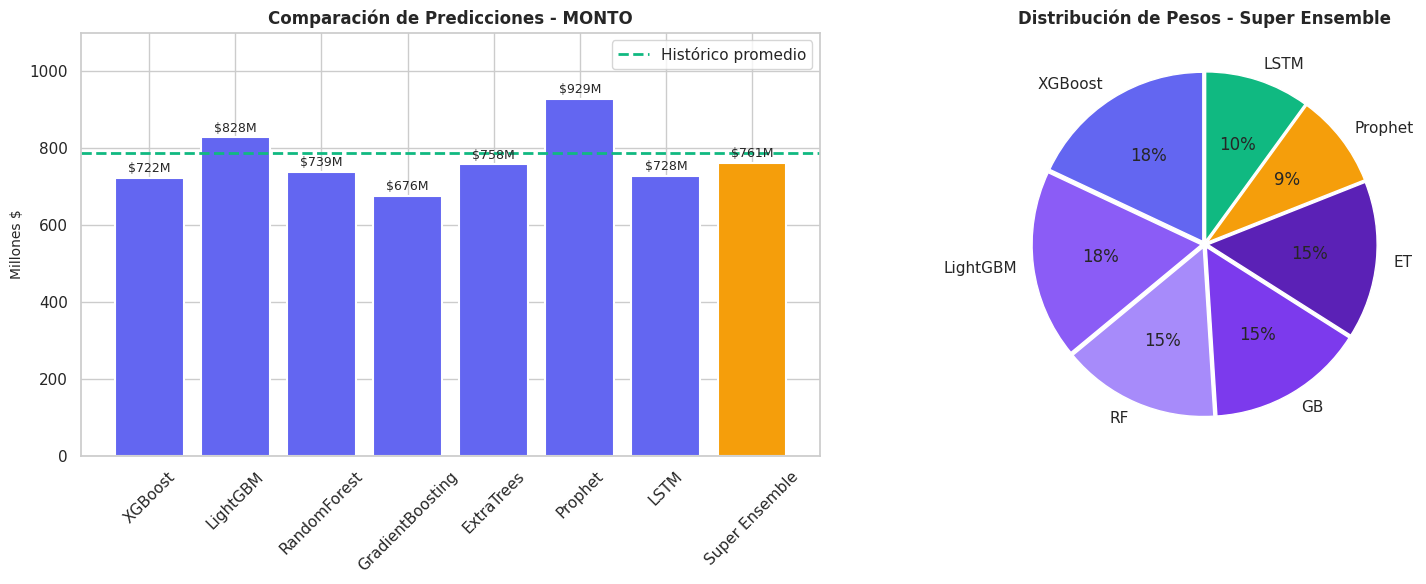


📊 Gráfico guardado: 05_predicciones.png


In [16]:
# ============================================================
# VISUALIZACIÓN DE PREDICCIONES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de predicciones de MONTO
modelos = ['XGBoost', 'LightGBM', 'RandomForest', 'GradientBoosting', 'ExtraTrees', 'Prophet', 'LSTM', 'Super Ensemble']
predicciones = [722, 828, 739, 676, 758, 929, 728, 761]
pesos = [18, 18, 15, 15, 15, 9, 10, 100]

colors = ['#6366f1' if m != 'Super Ensemble' else '#f59e0b' for m in modelos]
bars = axes[0].bar(modelos, predicciones, color=colors, edgecolor='white', linewidth=1.5)
axes[0].axhline(y=788, color='#10b981', linestyle='--', linewidth=2, label='Histórico promedio')
axes[0].set_title('Comparación de Predicciones - MONTO', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Millones $', fontsize=10)
axes[0].set_ylim(0, 1100)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Agregar valores en las barras
for bar, pred in zip(bars, predicciones):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, 
                f'${pred}M', ha='center', fontsize=9)

# Gráfico 2: Distribución de pesos del Super Ensemble
pesos_graf = [18, 18, 15, 15, 15, 9, 10]
modelos_pesos = ['XGBoost', 'LightGBM', 'RF', 'GB', 'ET', 'Prophet', 'LSTM']
colors_pesos = ['#6366f1', '#8b5cf6', '#a78bfa', '#7c3aed', '#5b21b6', '#f59e0b', '#10b981']

wedges, texts, autotexts = axes[1].pie(pesos_graf, labels=modelos_pesos, autopct='%1.0f%%',
                                      colors=colors_pesos, startangle=90,
                                      explode=[0.02]*7)
axes[1].set_title('Distribución de Pesos - Super Ensemble', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('05_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Gráfico guardado: 05_predicciones.png")


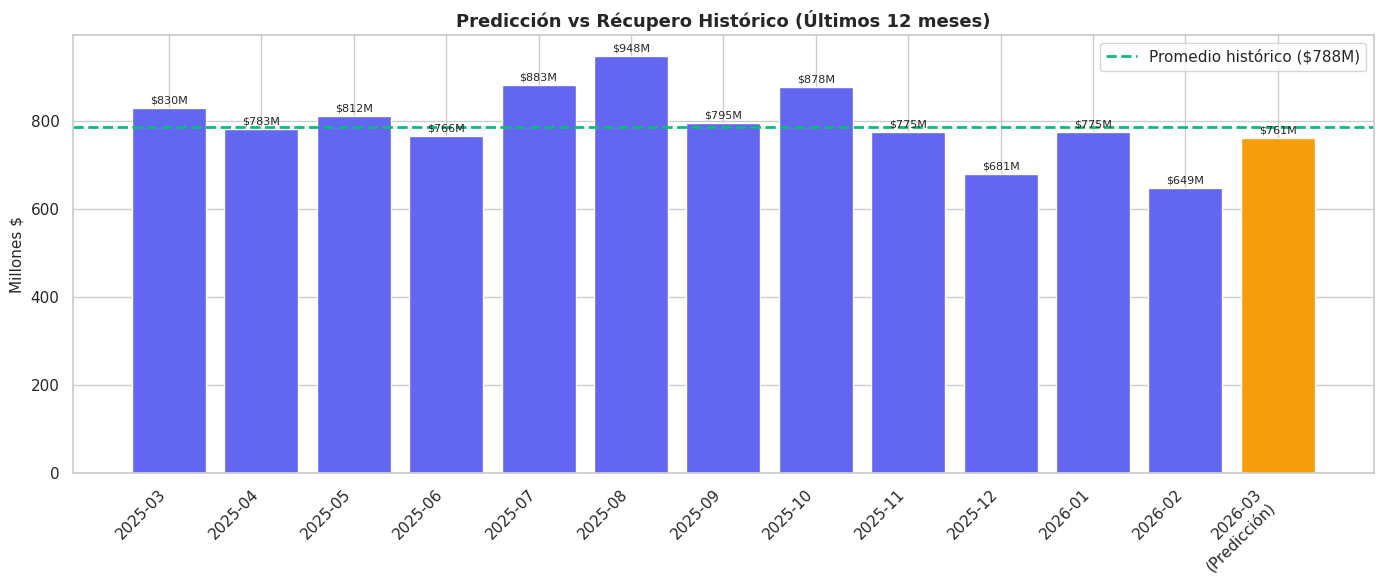


📊 Gráfico guardado: 06_prediccion_vs_historico.png


In [16]:
# ============================================================
# GRÁFICO: PREDICCIÓN vs RECUPERO HISTÓRICO
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Últimos 12 meses + predicción
ultimos_12 = historico.tail(12).copy()
ultimos_12['label'] = ultimos_12['AÑO_MES'].astype(str)

# Agregar predicción
pred_df = pd.DataFrame({
    'AÑO_MES': ['2026-03'],
    'monto_total': [761370000],
    'label': ['2026-03\n(Predicción)']
})

# Combinar
plot_data = pd.concat([ultimos_12, pred_df], ignore_index=True)

# Colores (predicción en diferente color)
colors = ['#6366f1'] * 12 + ['#f59e0b']

# Gráfico de barras
bars = ax.bar(range(len(plot_data)), plot_data['monto_total'] / 1e6, 
             color=colors, edgecolor='white', linewidth=1)

# Línea de promedio
ax.axhline(y=788, color='#10b981', linestyle='--', linewidth=2, 
           label=f'Promedio histórico ($788M)')

# Etiquetas
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data['label'], rotation=45, ha='right')
ax.set_ylabel('Millones $', fontsize=11)
ax.set_title('Predicción vs Récupero Histórico (Últimos 12 meses)', 
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right')

# Agregar valor en cada barra
for bar, val in zip(bars, plot_data['monto_total'] / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'${val:.0f}M', ha='center', fontsize=8, rotation=0)

plt.tight_layout()
plt.savefig('06_prediccion_vs_historico.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Gráfico guardado: 06_prediccion_vs_historico.png")
